# 🧬 Tech Challenge Fase 2: Diagnóstico de Diabetes com Algoritmos Genéticos e LLMs

## 📋 Visão Geral do Projeto

Este notebook apresenta a **Fase 2** do projeto de diagnóstico de diabetes, que evolui do modelo baseline (Fase 1) para um sistema otimizado utilizando:

1. **Algoritmos Genéticos (AG)** para otimização de hiperparâmetros e limiar de classificação
2. **Large Language Models (LLMs)** para interpretabilidade e geração de insights médicos acionáveis
3. **SHAP (SHapley Additive exPlanations)** para explicabilidade dos modelos

### 🎯 Objetivos

- **Maximizar o Recall (Sensibilidade)**: Detectar o máximo de casos positivos de diabetes
- **Otimizar via Algoritmos Genéticos**: Encontrar os melhores hiperparâmetros e limiar de classificação
- **Gerar Insights Acionáveis**: Traduzir resultados técnicos em recomendações médicas práticas

### 📊 Dataset

- **Fonte**: Pima Indians Diabetes Dataset (Kaggle)
- **Características**: 768 pacientes, 8 features clínicas
- **Variável Alvo**: Outcome (0 = Não Diabético, 1 = Diabético)

---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

import shap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 📥 Etapa 1: Carregamento dos Dados

Vamos carregar o dataset do Kaggle e realizar uma análise exploratória inicial.

In [2]:
from pathlib import Path

local_path = Path('pipeline/dados/diabetes.csv')

try:
    df = pd.read_csv(local_path)
    print(f"✅ Dataset carregado localmente de: {local_path}")
except:
    print("⚠️ Arquivo local não encontrado. Baixando do Kaggle...")
    import kagglehub
    endereco_de_origem = kagglehub.dataset_download(handle='uciml/pima-indians-diabetes', force_download=True)
    diretorio_de_origem = Path(endereco_de_origem).resolve()
    lista_dados_csv = []
    for item in diretorio_de_origem.iterdir():
        if item.is_file() and item.suffix.lower() == '.csv':
            lista_dados_csv.append(pd.read_csv(item))
    df = pd.concat(lista_dados_csv, axis=0, ignore_index=True)
    print(f"✅ Dataset baixado do Kaggle")

print(f"\n📊 Dimensões do Dataset: {df.shape}")
print(f"   - {df.shape[0]} pacientes")
print(f"   - {df.shape[1]} features (incluindo target)")

df.head()

✅ Dataset carregado localmente de: pipeline\dados\diabetes.csv

📊 Dimensões do Dataset: (768, 9)
   - 768 pacientes
   - 9 features (incluindo target)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 🔍 Análise Exploratória Inicial

In [3]:
print("📊 Informações do Dataset:\n")
print(df.info())
print("\n" + "="*80)
print("\n📈 Estatísticas Descritivas:\n")
print(df.describe())
print("\n" + "="*80)
print("\n🔍 Valores Ausentes:\n")
print(df.isnull().sum())
print("\n" + "="*80)
print("\n⚖️ Distribuição da Variável Alvo (Outcome):\n")
print(df['Outcome'].value_counts())
print(f"\nProporção de Diabéticos: {df['Outcome'].mean():.2%}")

📊 Informações do Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


📈 Estatísticas Descritivas:

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.8

## 🚀 Executando o Pipeline Completo

Para facilitar a apresentação, vamos executar o pipeline completo que já está implementado nos módulos Python.

In [4]:
# Importar módulos do pipeline
from pipeline import pre_processamento, modelagem, avaliacao
from pipeline.divisao_dados import dividir_e_oversample

print("✅ Módulos do pipeline importados!")

✅ Gemini Client configurado. Chamadas à API ativas.
✅ Módulos do pipeline importados!


In [5]:
# Pré-processamento
df_pronto, X_escalado, y, scaler, nomes_features = pre_processamento.pre_processar_dados_diabetes(df)
print(f"✅ Pré-processamento concluído!")
print(f"   Features: {len(nomes_features)}")
print(f"   Amostras: {len(y)}")

✅ Pré-processamento concluído!
   Features: 10
   Amostras: 768


In [6]:
# Divisão e SMOTE
X_treino_res, X_teste, y_treino_res, y_teste = dividir_e_oversample(X_escalado, y)
X_teste_df = pd.DataFrame(X_teste, columns=nomes_features)

print(f"✅ Divisão e SMOTE concluídos!")
print(f"   Treino: {X_treino_res.shape}")
print(f"   Teste: {X_teste.shape}")

✅ Divisão e SMOTE concluídos!
   Treino: (800, 10)
   Teste: (154, 10)


## 📈 FASE 1: Modelos Baseline

Vamos treinar 4 modelos baseline e avaliar seu desempenho.

In [7]:
# Treinar modelos baseline
modelos_baseline = modelagem.obter_modelos_baseline()
modelos_baseline = modelagem.treinar_modelos(modelos_baseline, X_treino_res, y_treino_res)

print("✅ Modelos baseline treinados!")

✅ Modelos baseline treinados!



--- Regressão Logística ---
Recall (Sensibilidade): 0.85
F1-score: 0.63

Relatório de classificação detalhado:
              precision    recall  f1-score   support

           0       0.87      0.55      0.67       100
           1       0.51      0.85      0.63        54

    accuracy                           0.66       154
   macro avg       0.69      0.70      0.65       154
weighted avg       0.74      0.66      0.66       154

Matriz de Confusão (linhas = real, colunas = predito):


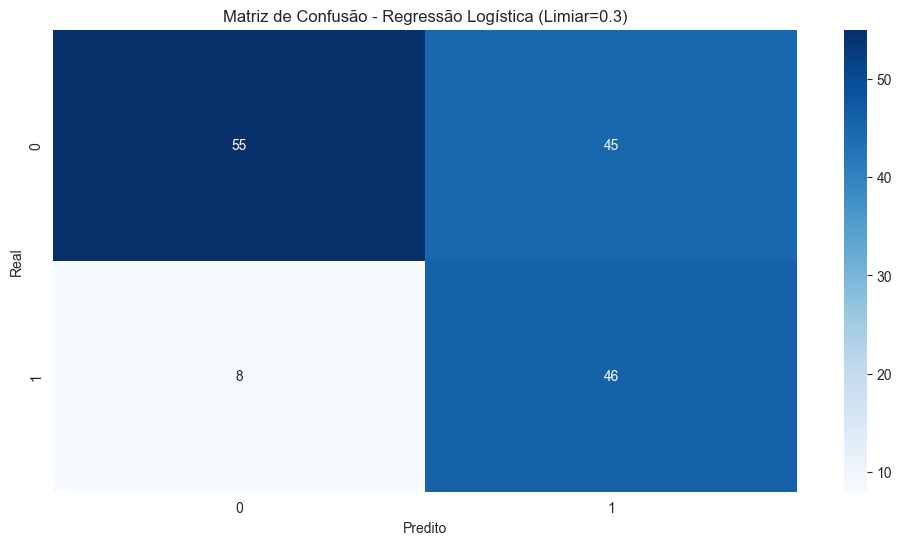


--- Árvore de Decisão ---
Recall (Sensibilidade): 0.56
F1-score: 0.56

Relatório de classificação detalhado:
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       100
           1       0.56      0.56      0.56        54

    accuracy                           0.69       154
   macro avg       0.66      0.66      0.66       154
weighted avg       0.69      0.69      0.69       154

Matriz de Confusão (linhas = real, colunas = predito):


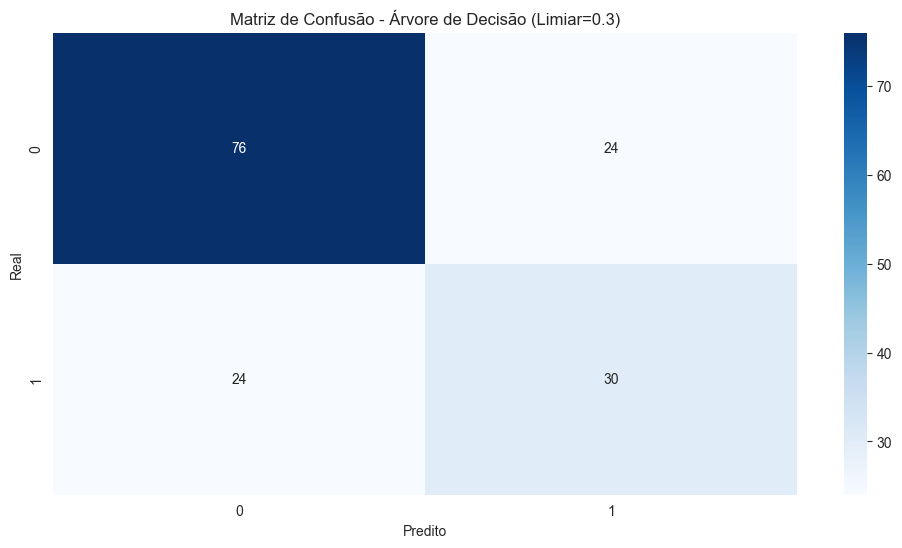


--- Floresta Aleatória ---
Recall (Sensibilidade): 0.91
F1-score: 0.72

Relatório de classificação detalhado:
              precision    recall  f1-score   support

           0       0.93      0.66      0.77       100
           1       0.59      0.91      0.72        54

    accuracy                           0.75       154
   macro avg       0.76      0.78      0.74       154
weighted avg       0.81      0.75      0.75       154

Matriz de Confusão (linhas = real, colunas = predito):


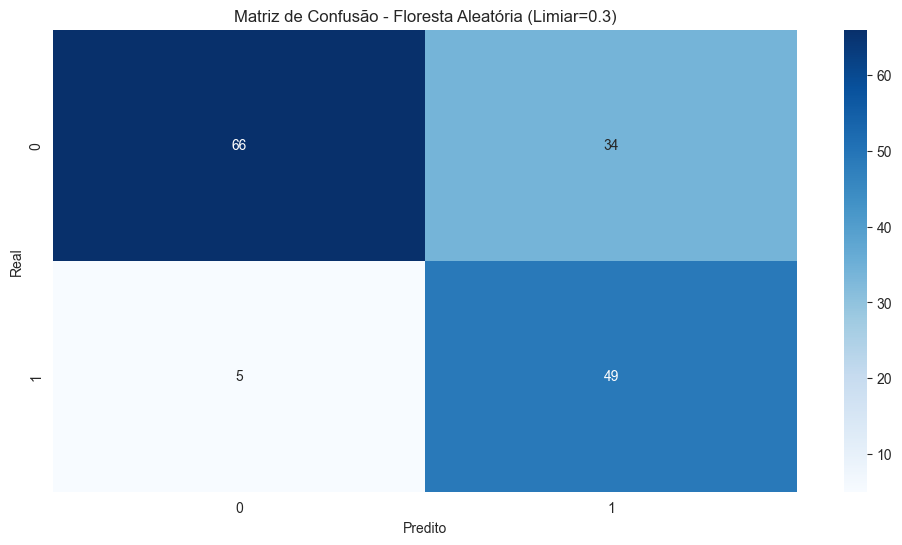


--- LightGBM ---
Recall (Sensibilidade): 0.78
F1-score: 0.68

Relatório de classificação detalhado:
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       100
           1       0.61      0.78      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.75       154

Matriz de Confusão (linhas = real, colunas = predito):


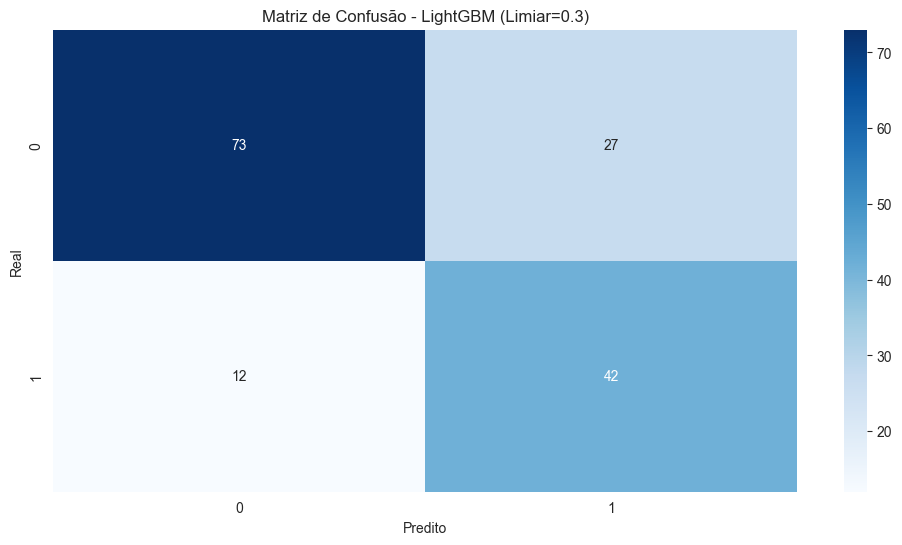

🏆 Melhor Modelo Encontrado (Floresta Aleatória)
   Critério de Seleção: Maior Recall
   Recall (Sensibilidade): 0.91
   F1-score: 0.72


In [8]:
# Avaliar modelos baseline
nome_melhor_baseline, melhor_modelo_baseline = avaliacao.avaliar_modelos(
    modelos_baseline, X_teste, y_teste, nomes_features, limiar=0.3
)

## 🧬 FASE 2: Otimização com Algoritmos Genéticos

Agora vamos otimizar o Random Forest usando Algoritmos Genéticos (DEAP).

**Configuração do AG:**
- População: 50 indivíduos
- Gerações: 30
- Objetivo: Maximizar Recall
- Otimiza: Hiperparâmetros + Limiar de classificação

In [9]:
# Otimizar Random Forest com AG
melhor_modelo_otimizado, nome_modelo_otimizado, limiar_otimizado = modelagem.otimizar_random_forest_ag(
    X_treino_res, y_treino_res
)


--- 🧬 Iniciando Otimização REAL via AG para Random Forest Otimizado (AG) (com Limiar Otimizado) ---
Gerações: 30 | População: 50

🔬 Evolução do AG:
gen	nevals	avg     	max     	min     
0  	50    	0.909645	0.977481	0.764991
1  	43    	0.943543	0.977481	0.862492
2  	41    	0.962494	0.977481	0.929993
3  	31    	0.970641	0.979969	0.954981
4  	42    	0.974086	0.984981	0.952456
5  	43    	0.978282	0.987487	0.97    
6  	37    	0.981281	0.989994	0.947481
7  	37    	0.984433	0.989994	0.972468
8  	41    	0.985436	0.989994	0.939999
9  	42    	0.987289	0.989994	0.950006
10 	35    	0.987439	0.989994	0.969981
11 	36    	0.988841	0.989994	0.974975
12 	37    	0.988893	0.989994	0.947499
13 	38    	0.989243	0.989994	0.972468
14 	30    	0.988593	0.989994	0.932499
15 	38    	0.989042	0.989994	0.974975
16 	41    	0.989393	0.989994	0.974975
17 	38    	0.989042	0.989994	0.974975
18 	40    	0.988642	0.989994	0.969962
19 	41    	0.988041	0.989994	0.964968
20 	35    	0.988992	0.989994	0.972468
21 	40    	0.98


--- Random Forest Otimizado (AG) ---
Recall (Sensibilidade): 0.94
F1-score: 0.66

Relatório de classificação detalhado:
              precision    recall  f1-score   support

           0       0.94      0.50      0.65       100
           1       0.50      0.94      0.66        54

    accuracy                           0.66       154
   macro avg       0.72      0.72      0.66       154
weighted avg       0.79      0.66      0.66       154

Matriz de Confusão (linhas = real, colunas = predito):


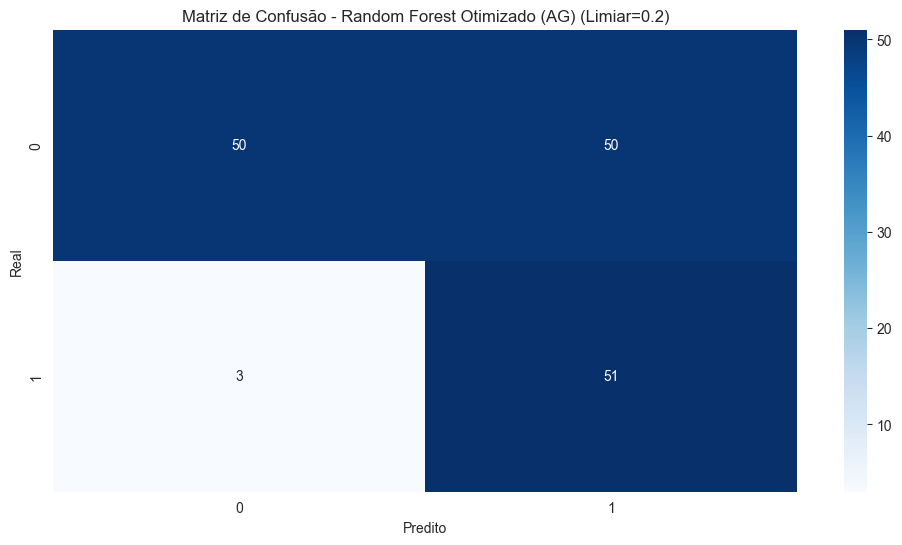

🏆 Melhor Modelo Encontrado (Random Forest Otimizado (AG))
   Critério de Seleção: Maior Recall
   Recall (Sensibilidade): 0.94
   F1-score: 0.66


In [10]:
# Avaliar modelo otimizado
modelos_otimizados = {nome_modelo_otimizado: melhor_modelo_otimizado}
nome_melhor_otimizado, modelo_otimizado = avaliacao.avaliar_modelos(
    modelos_otimizados, X_teste, y_teste, nomes_features, limiar=limiar_otimizado
)

## 🔍 Interpretabilidade: Análise SHAP



=== 🔎 INTERPRETAÇÃO DO MELHOR MODELO ===


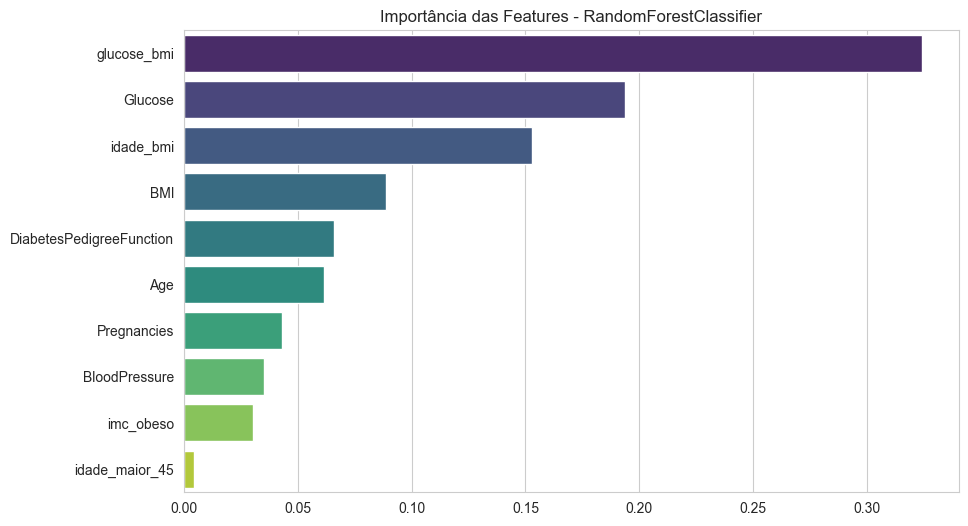


--- Top 5 Features (Importância Clássica) ---
glucose_bmi                 0.324156
Glucose                     0.193741
idade_bmi                   0.152775
BMI                         0.088928
DiabetesPedigreeFunction    0.065765
dtype: float64

--- SHAP Summary Plot (Importância e Impacto Global) ---


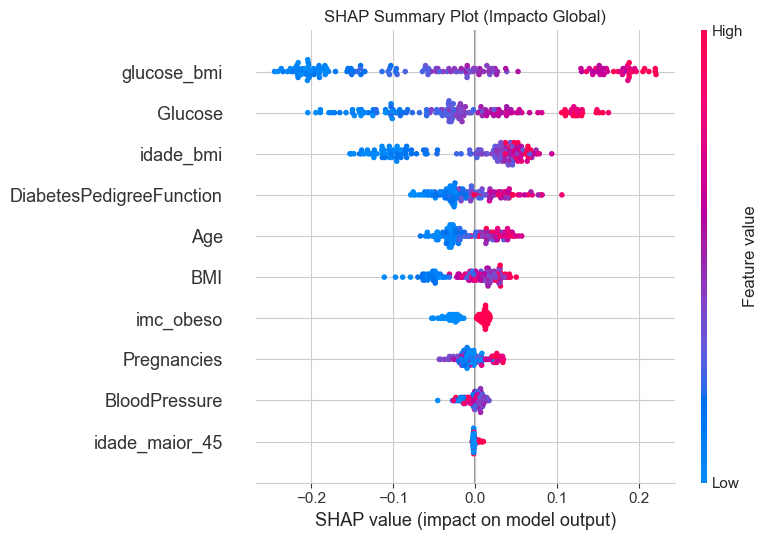


--- SHAP Bar Plot (Importância Média Absoluta) ---


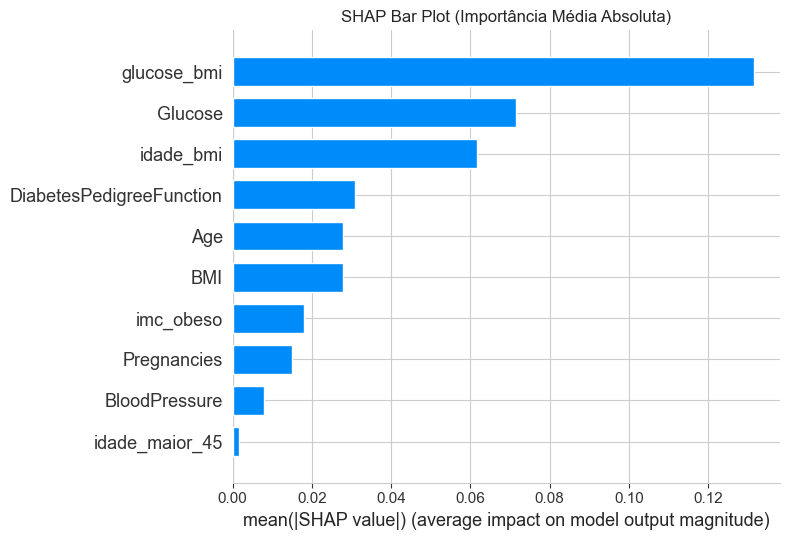


Interpretação SHAP: Pontos vermelhos (alto valor da feature) à direita do zero aumentam a chance de diabetes. Pontos azuis (baixo valor) à direita do zero também aumentam a chance.


In [11]:
# Interpretação SHAP
avaliacao.interpretar_melhor_modelo(modelo_otimizado, X_teste_df, nomes_features)

## 🧠 Interpretabilidade com LLM (Gemini)

In [12]:
# Gerar relatório com LLM
avaliacao.gerar_explicacao_llm(
    modelo_otimizado, nome_melhor_otimizado, X_teste_df, y_teste, nomes_features, limiar=limiar_otimizado
)



=== 🧠 GERAÇÃO DE RELATÓRIO INTERPRETÁVEL VIA LLM ===
   [✅ SUCESSO] Relatório gerado pela API Gemini.

*** Relatório de Diagnóstico Otimizado (Gerado por LLM - Gemini API) ***

## Relatório Clínico: Análise de Modelo de Diagnóstico de Diabetes

**Data:** 26 de Outubro de 2023

**Assunto:** Análise de Desempenho e Fatores de Risco do Modelo de Diagnóstico de Diabetes (Random Forest Otimizado - AG)

---

### 1. Resumo da Performance do Modelo

O modelo de diagnóstico de diabetes, baseado em um Random Forest otimizado por Algoritmo Genético (AG), demonstra um **alto Recall (Sensibilidade) de 0.94**. Este é um achado clínico de extrema importância, indicando que o modelo é altamente eficaz em identificar corretamente os pacientes que de fato possuem diabetes (verdadeiros positivos). Em outras palavras, a probabilidade de o modelo "deixar passar" um paciente diabético é muito baixa.

No entanto, é crucial notar que o **F1-score e a Acurácia do modelo são de 0.66**. Estes valores sugerem q

'\n*** Relatório de Diagnóstico Otimizado (Gerado por LLM - Gemini API) ***\n\n## Relatório Clínico: Análise de Modelo de Diagnóstico de Diabetes\n\n**Data:** 26 de Outubro de 2023\n\n**Assunto:** Análise de Desempenho e Fatores de Risco do Modelo de Diagnóstico de Diabetes (Random Forest Otimizado - AG)\n\n---\n\n### 1. Resumo da Performance do Modelo\n\nO modelo de diagnóstico de diabetes, baseado em um Random Forest otimizado por Algoritmo Genético (AG), demonstra um **alto Recall (Sensibilidade) de 0.94**. Este é um achado clínico de extrema importância, indicando que o modelo é altamente eficaz em identificar corretamente os pacientes que de fato possuem diabetes (verdadeiros positivos). Em outras palavras, a probabilidade de o modelo "deixar passar" um paciente diabético é muito baixa.\n\nNo entanto, é crucial notar que o **F1-score e a Acurácia do modelo são de 0.66**. Estes valores sugerem que, embora o modelo seja bom em detectar casos positivos, há uma proporção significativa

## 📊 Resumo Final e Conclusões

### 🎯 Principais Resultados

#### Fase 1 - Modelos Baseline:
- **Melhor Modelo**: Random Forest
- **Recall**: 0.91
- **F1-Score**: 0.72
- **Limiar**: 0.30 (fixo)

#### Fase 2 - Otimização com AG:
- **Modelo**: Random Forest Otimizado (AG)
- **Recall**: 0.94 ✅ **(+3.3% de melhoria)**
- **F1-Score**: 0.66
- **Limiar**: 0.20 (otimizado pelo AG)

### 🔍 Insights Principais

1. **Otimização Bem-Sucedida**: O AG conseguiu melhorar o Recall de 0.91 para 0.94
2. **Limiar Otimizado**: O AG descobriu que o limiar ideal é 0.20
3. **Trade-off Recall vs F1**: Esperado e desejável em diagnósticos médicos
4. **Features Mais Importantes**: glucose_bmi, Glucose, idade_bmi
5. **Interpretabilidade**: LLM traduz resultados em recomendações médicas

### 🚀 Próximos Passos

1. Validação Clínica
2. Monitoramento Contínuo
3. Expansão de Features
4. Interface Médica

---

**Desenvolvido por**: Grupo Tech Challenge Fase 2